# Wine Quality Prediction 

This project aims to predict wine quality using the chemical properties of wines.

Quality control is a critical process in wine production. Machine learning techniques can be used to predict wine quality based on chemical components.

In this project, a machine learning model will be developed to predict the quality score of wines using their chemical characteristics.

<img src='https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSLVba5bj6LEzTCBPgXOKTX5s3kUgxQv7SvcIupvoHVVg&s=10' width='750'>

In [2]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# EDA

In [3]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

train.head()

,Id,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,0,8.0,0.50,0.39,2.2,0.073,30.0,39.0,0.99572,3.33,0.77,12.1,6
1,1,9.3,0.30,0.73,2.3,0.092,30.0,67.0,0.99854,3.32,0.67,12.8,6
2,2,7.1,0.51,0.03,2.1,0.059,3.0,12.0,0.99660,3.52,0.73,11.3,7
3,3,8.1,0.87,0.22,2.6,0.084,11.0,65.0,0.99730,3.20,0.53,9.8,5
4,4,8.5,0.36,0.30,2.3,0.079,10.0,45.0,0.99444,3.20,1.36,9.5,6


In [4]:
train.shape, test.shape

((2056, 13), (1372, 12))

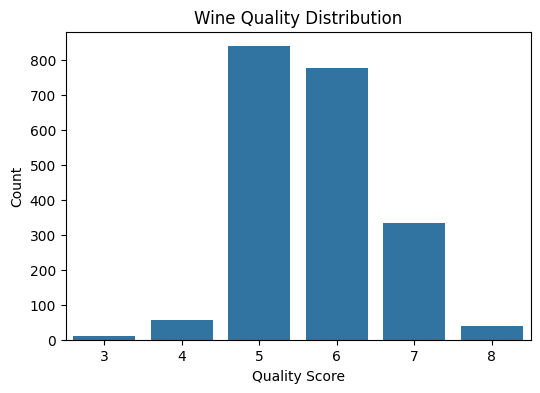

In [5]:
#Target Distribution
plt.figure(figsize=(6,4))

sns.countplot(x=train["quality"])

plt.title("Wine Quality Distribution")
plt.xlabel("Quality Score")
plt.ylabel("Count")

plt.show()

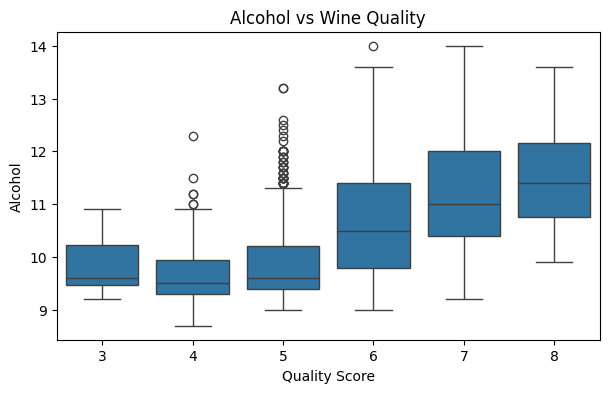

In [7]:
#Alcohol vs Wine Quality
plt.figure(figsize=(7,4))

sns.boxplot(x="quality", y="alcohol", data=train)

plt.title("Alcohol vs Wine Quality")
plt.xlabel("Quality Score")
plt.ylabel("Alcohol")

plt.show()


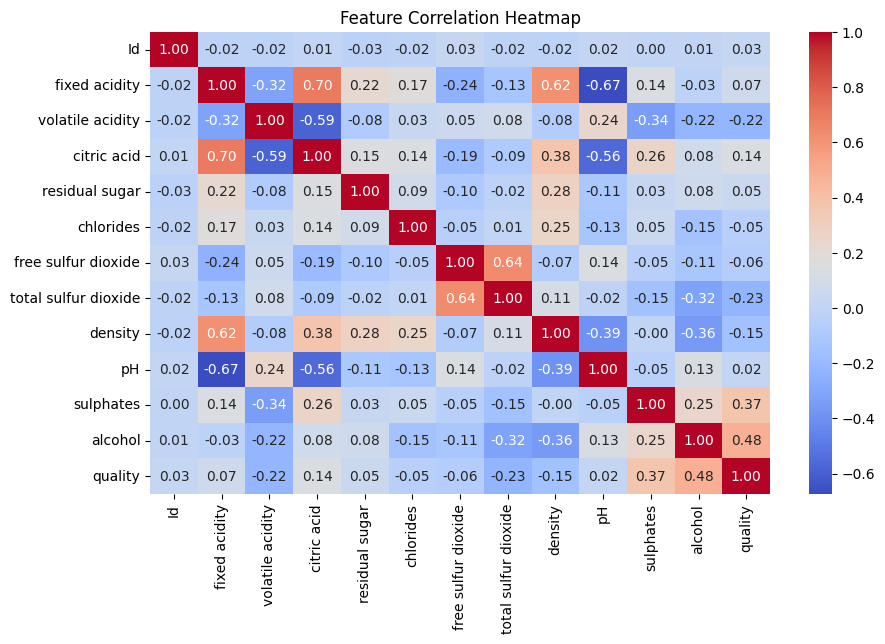

In [8]:
#Correlation Heatmap
plt.figure(figsize=(10,6))

corr = train.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Feature Correlation Heatmap")

plt.show()

### Modeling

In [10]:
x = train.drop("quality", axis=1)
y = train["quality"]

In [11]:
from sklearn.model_selection import train_test_split

x_train, x_valid, y_train, y_valid = train_test_split(x,y,test_size=0.2,random_state=42)

In [13]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=800,max_depth=10,random_state=42)

model.fit(x_train, y_train)

,n_estimators,800
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [14]:
from sklearn.metrics import accuracy_score

pred_valid = model.predict(x_valid)

accuracy_score(y_valid, pred_valid)

0.5655339805825242

In [15]:
test_pred = model.predict(test)

In [16]:
submission = pd.DataFrame({
    "quality": test_pred
})

submission.to_csv("submission.csv", index=False)
submission.head()

,quality
0,6
1,6
2,6
3,6
4,5


In this project, a Random Forest classifier was used to predict wine quality.

The model achieved approximately 56% validation accuracy on the validation set. This result shows that the model is able to learn certain patterns related to wine quality, but additional improvements are needed to achieve stronger predictive performance.

This dataset represents a multiclass classification problem with multiple quality levels. In addition, class imbalance and the relatively small representation of some quality categories may have limited the model performance.

Despite this limitation, the model still demonstrates that chemical properties contain meaningful signals for predicting wine quality. Features such as alcohol, sulphates, and volatile acidity appear to play an important role in wine quality prediction. 